In [23]:
import pandas as pd
import numpy as np

# Load the entire quantum data and classical benchmark data
df_quantum = pd.read_csv('out.csv')
df_classical = pd.read_csv('out_classical.csv')

# Merge the dataframes, handling duplicate column names with suffixes
df_merged = pd.merge(df_quantum, df_classical, on=['conf_cluster_type', 'conf_target_id'], how='left', suffixes=('_quantum', '_classical'))

# Define grouping columns for unique runs
group_cols = ['conf_qubit_alloc', 'conf_cluster_type', 'conf_target_id', 'conf_qaoa_depth', 'shots']

# Group the merged data
grouped = df_merged.groupby(group_cols)

# Calculate key metrics for each unique run configuration
df_group_stats = grouped.apply(lambda x: pd.Series({
    'expected_cost': (x['cost'] * x['count']).sum() / x['count'].sum() if x['count'].sum() != 0 else np.nan,
    'total_valid_counts': x['count'].sum(),
    'invalid_shots': x['shots'].iloc[0] - x['count'].sum(),
    'optimal_attemps': x[x['cost'] == x['benchmark_min_cost_classical']]['count'].sum()
})).reset_index()

# Merge the calculated stats back to a dataframe of unique run configurations
df_unique_groups = df_merged.drop_duplicates(subset=group_cols).copy()
df_final = pd.merge(df_unique_groups, df_group_stats, on=group_cols, how='left')

# Calculate the optimality ratio
df_final['optimality_ratio'] = df_final['benchmark_min_cost_classical'] / df_final['expected_cost']

# --- Part 1: Generate the detailed table for all instances ---
print("\n--- Optimality Ratio for All Instances ---")
# Filter out rows where optimality_ratio is NaN (due to zero total_count)
df_valid_optimality = df_final
print(df_valid_optimality[['conf_qubit_alloc', 'conf_target_id', 'conf_qaoa_depth', 'shots', 'optimality_ratio']])
print(f"\nTotal number of instances with valid optimality ratio: {len(df_valid_optimality)}")


--- Optimality Ratio for All Instances ---
   conf_qubit_alloc  conf_target_id  conf_qaoa_depth  shots  optimality_ratio
0   naive_adjacency              56                3    512          1.000000
1   node_visit_time              56                3    512          0.943240
2   naive_adjacency             108                3    512          1.000000
3   node_visit_time             108                3    512          1.000000
4   naive_adjacency              47                3    512          1.000000
5   node_visit_time              47                3    512          0.750097
6   naive_adjacency               5                3    512               NaN
7   node_visit_time               5                3    512          0.786412
8   naive_adjacency             103                3    512               NaN
9   node_visit_time             103                3    512          1.000000
10  naive_adjacency              63                3    512               NaN
11  node_visit_time 

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3536\3331197924.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_group_stats = grouped.apply(lambda x: pd.Series({


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3536\2938498916.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_group_stats = grouped.apply(lambda x: pd.Series({



--- Invalid Bitstring Measurements ---


--- Invalid Bitstring Measurements for All Instances ---
   conf_qubit_alloc  conf_target_id  conf_qaoa_depth  shots  \
0   naive_adjacency              56                3    512   
1   node_visit_time              56                3    512   
2   naive_adjacency             108                3    512   
3   node_visit_time             108                3    512   
4   naive_adjacency              47                3    512   
5   node_visit_time              47                3    512   
6   naive_adjacency               5                3    512   
7   node_visit_time               5                3    512   
8   naive_adjacency             103                3    512   
9   node_visit_time             103                3    512   
10  naive_adjacency              63                3    512   
11  node_visit_time              63                3    512   
12  naive_adjacency              78                3    512   
13  node_visit_time

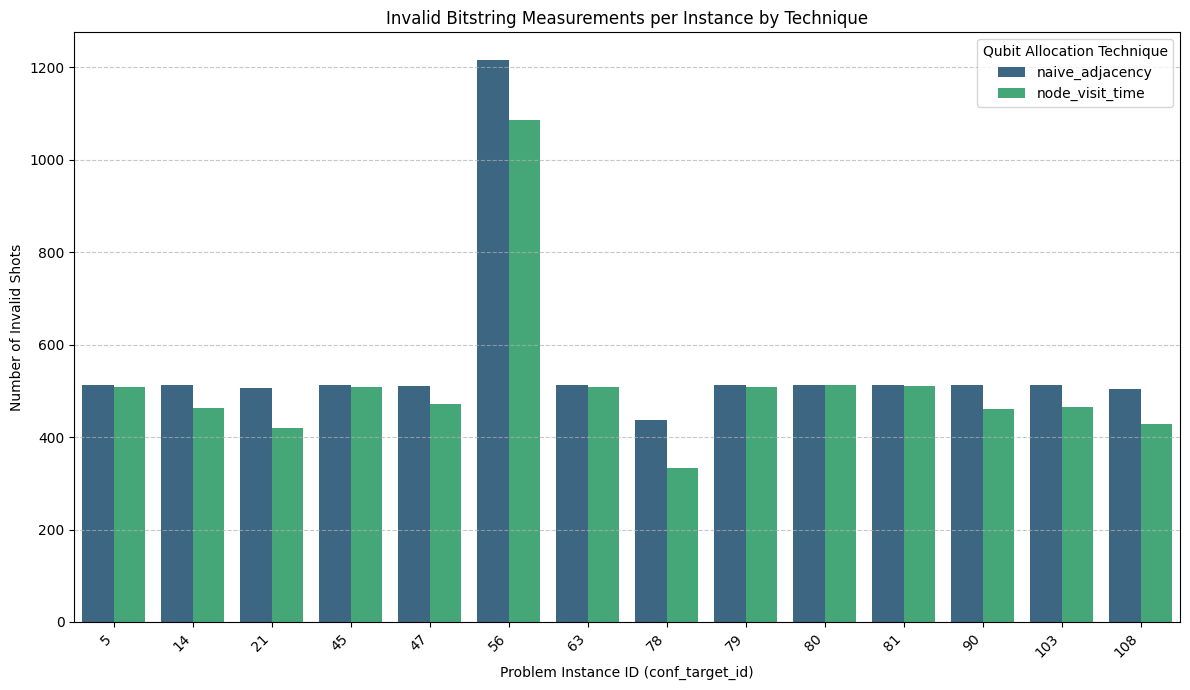

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load the entire quantum data and classical benchmark data
df_quantum = pd.read_csv('out.csv')
df_classical = pd.read_csv('out_classical.csv')

# Merge the dataframes, handling duplicate column names with suffixes
df_merged = pd.merge(df_quantum, df_classical, on=['conf_cluster_type', 'conf_target_id'], how='left', suffixes=('_quantum', '_classical'))

# Define grouping columns for unique runs
group_cols = ['conf_qubit_alloc', 'conf_cluster_type', 'conf_target_id', 'conf_qaoa_depth', 'shots']

# Group the merged data
grouped = df_merged.groupby(group_cols)

# Calculate key metrics for each unique run configuration
df_group_stats = grouped.apply(lambda x: pd.Series({
    'expected_cost': (x['cost'] * x['count']).sum() / x['count'].sum() if x['count'].sum() != 0 else np.nan,
    'total_valid_counts': x['count'].sum(),
    'invalid_shots': x['shots'].iloc[0] - x['count'].sum(),
    'optimal_attemps': x[x['cost'] == x['benchmark_min_cost_classical']]['count'].sum()
})).reset_index()

# After df_group_stats is created, explicitly cast the columns to integer type
df_group_stats['total_valid_counts'] = df_group_stats['total_valid_counts'].astype(int)
df_group_stats['invalid_shots'] = df_group_stats['invalid_shots'].astype(int)

# Merge the calculated stats back to a dataframe of unique run configurations
df_unique_groups = df_merged.drop_duplicates(subset=group_cols).copy()
df_final = pd.merge(df_unique_groups, df_group_stats, on=group_cols, how='left')

# Calculate the optimality ratio (though not strictly needed for this part, it's part of the df_final generation)
df_final['optimality_ratio'] = df_final['benchmark_min_cost_classical'] / df_final['expected_cost']

# --- Start of "Invalid Bitstring Measurements" (Point 2 from PDF) ---

print("\n" + "="*80) # Separator for clarity
print("--- Invalid Bitstring Measurements ---")
print("="*80 + "\n")

# Detailed table for all instances showing invalid bitstrings
print("\n--- Invalid Bitstring Measurements for All Instances ---")
# Display relevant columns for understanding invalid bitstrings.
# 'invalid_shots' is already calculated in df_group_stats and merged into df_final.
print(df_final[['conf_qubit_alloc', 'conf_target_id', 'conf_qaoa_depth', 'shots', 'total_valid_counts', 'invalid_shots']])
print(f"\nTotal number of instances analyzed for invalid bitstrings: {len(df_final)}")

# --- Graph for Invalid Bitstring Measurements for All Instances ---
# This graph visualizes the invalid shots for each problem instance,
# with different colors for each qubit allocation technique.
plt.figure(figsize=(12, 7)) # Set the figure size for better readability
sns.barplot(x='conf_target_id', y='invalid_shots', hue='conf_qubit_alloc', data=df_final, palette='viridis', errorbar=None) # Added errorbar=None

plt.title('Invalid Bitstring Measurements per Instance by Technique')
plt.xlabel('Problem Instance ID (conf_target_id)')
plt.ylabel('Number of Invalid Shots')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels to prevent overlap if many instances
plt.legend(title='Qubit Allocation Technique')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.savefig('pi2.png')

# Summary table for invalid bitstrings grouped by technique
summary_invalid_bitstrings = df_final.groupby('conf_qubit_alloc').agg(
    avg_invalid_shots=('invalid_shots', 'mean'),
    std_invalid_shots=('invalid_shots', 'std'),
    total_invalid_shots=('invalid_shots', 'sum'),
    total_shots=('shots', 'sum') # Sum of shots across all instances for each technique
).reset_index()

# Rename the first column for clarity as 'technique'
summary_invalid_bitstrings.rename(columns={'conf_qubit_alloc': 'technique'}, inplace=True)

print("\n--- Summary of Invalid Bitstring Measurements by Technique ---")
print(summary_invalid_bitstrings)

# Additional insight: Percentage of invalid shots
# This calculates the overall percentage of invalid shots for each technique.
summary_invalid_bitstrings['percentage_invalid_shots'] = (summary_invalid_bitstrings['total_invalid_shots'] / summary_invalid_bitstrings['total_shots']) * 100
print("\n--- Summary with Percentage of Invalid Shots ---")
print(summary_invalid_bitstrings[['technique', 'avg_invalid_shots', 'percentage_invalid_shots']])

In [25]:
summary_table = df_final.groupby('conf_qubit_alloc').agg(
    avg_opt_ratio=('optimality_ratio', 'mean'),
    std_opt_ratio=('optimality_ratio', 'std'),
    failed_attempts=('optimality_ratio', lambda x: x.isna().sum()),
    success_attempts=('optimality_ratio', lambda x: x.notna().sum()),
    optimal_attempts=('optimality_ratio', lambda x: np.isclose(x, 1).sum())
).reset_index()

# Rename the first column for clarity
summary_table.rename(columns={'conf_qubit_alloc': 'technique'}, inplace=True)

print("\n--- Summary of Naive Adjacency vs Node Visit Time ---")
print(summary_table)


--- Summary of Naive Adjacency vs Node Visit Time ---
         technique  avg_opt_ratio  std_opt_ratio  failed_attempts  \
0  naive_adjacency       0.987150       0.027566               13   
1  node_visit_time       0.928273       0.078774                2   

   success_attempts  optimal_attempts  
0                10                 8  
1                21                 4  



--- Comparison Between Shots ---


--- Optimality Ratio vs. Shots for 'node_visit_time' (conf_target_id=56) ---
    shots  optimality_ratio  expected_cost  benchmark_min_cost_classical
32    128          0.945095      19.017765                     17.973597
33    256          0.958786      18.746203                     17.973597
1     512          0.943240      19.055172                     17.973597
34   1024          0.951157      18.896558                     17.973597
39   1024          0.939199      19.137157                     17.973597
41   1024          0.953952      18.841203                     17.973597
43   1024          0.951884      18.882128                     17.973597
45   1024          0.950343      18.912741                     17.973597
35   2048          0.957661      18.768215                     17.973597
36   4096          0.950569      18.908241                     17.973597

Number of data points for this comparison: 10


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3536\3065082847.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_group_stats = grouped.apply(lambda x: pd.Series({
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3536\3065082847.py:53: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='shots', y='optimality_ratio', data=shots_comparison_data, marker='o', palette='viridis')


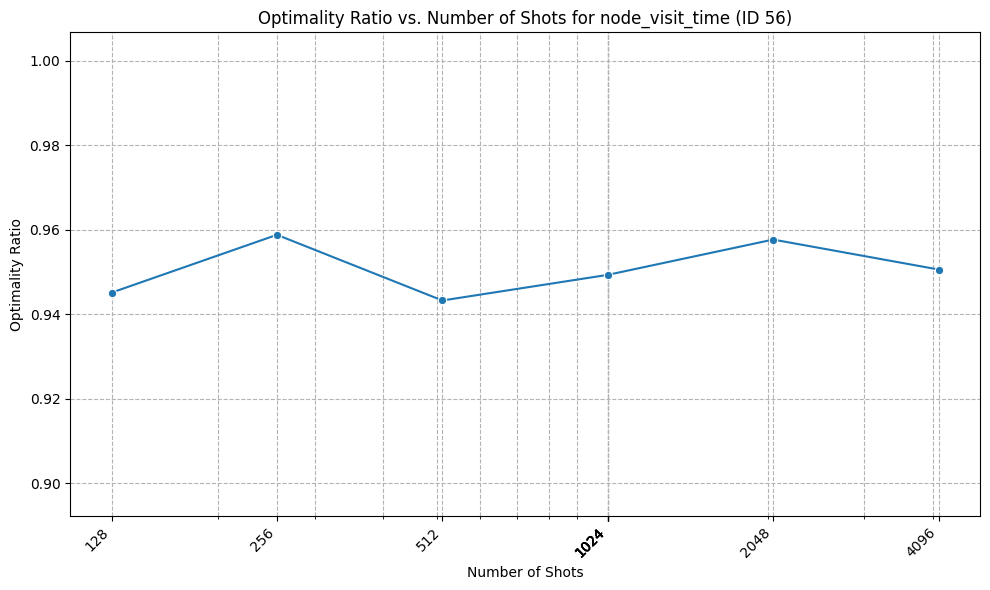

In [26]:
# Load the entire quantum data and classical benchmark data
df_quantum = pd.read_csv('out.csv')
df_classical = pd.read_csv('out_classical.csv')

# Merge the dataframes, handling duplicate column names with suffixes
df_merged = pd.merge(df_quantum, df_classical, on=['conf_cluster_type', 'conf_target_id'], how='left', suffixes=('_quantum', '_classical'))

# Define grouping columns for unique runs
group_cols = ['conf_qubit_alloc', 'conf_cluster_type', 'conf_target_id', 'conf_qaoa_depth', 'shots']

# Group the merged data
grouped = df_merged.groupby(group_cols)

# Calculate key metrics for each unique run configuration
df_group_stats = grouped.apply(lambda x: pd.Series({
    'expected_cost': (x['cost'] * x['count']).sum() / x['count'].sum() if x['count'].sum() != 0 else np.nan,
    'total_valid_counts': x['count'].sum(),
    'invalid_shots': x['shots'].iloc[0] - x['count'].sum(),
    # Use np.isclose for floating-point comparison
    'optimal_attemps': x[np.isclose(x['cost'], x['benchmark_min_cost_classical'])]['count'].sum()
})).reset_index()

# Merge the calculated stats back to a dataframe of unique run configurations
df_unique_groups = df_merged.drop_duplicates(subset=group_cols).copy()
df_final = pd.merge(df_unique_groups, df_group_stats, on=group_cols, how='left')

# Calculate the optimality ratio
df_final['optimality_ratio'] = df_final['benchmark_min_cost_classical'] / df_final['expected_cost']

# --- Start of "Comparison Between Shots" Analysis (Point 4 from PDF) ---

print("\n" + "="*80) # Separator for clarity
print("--- Comparison Between Shots ---")
print("="*80 + "\n")

# Filter data for the specific instance as per your request
# conf_qubit_alloc: 'node_visit_time', conf_target_id: 56
shots_comparison_data = df_final[
    (df_final['conf_qubit_alloc'] == 'node_visit_time') &
    (df_final['conf_target_id'] == 56)
].copy() # Use .copy() to avoid SettingWithCopyWarning

# Sort by shots for better visualization
shots_comparison_data = shots_comparison_data.sort_values(by='shots')

print(f"\n--- Optimality Ratio vs. Shots for 'node_visit_time' (conf_target_id=56) ---")
print(shots_comparison_data[['shots', 'optimality_ratio', 'expected_cost', 'benchmark_min_cost_classical']])
print(f"\nNumber of data points for this comparison: {len(shots_comparison_data)}")


# Graph: Optimality Ratio vs. Shots
plt.figure(figsize=(10, 6))
sns.lineplot(x='shots', y='optimality_ratio', data=shots_comparison_data, marker='o', palette='viridis')

plt.title('Optimality Ratio vs. Number of Shots for node_visit_time (ID 56)')
plt.xlabel('Number of Shots')
plt.ylabel('Optimality Ratio')
plt.xscale('log') # Use a logarithmic scale for shots if they vary widely
plt.xticks(shots_comparison_data['shots'], labels=shots_comparison_data['shots'], rotation=45, ha='right') # Set specific x-ticks
plt.ylim(shots_comparison_data['optimality_ratio'].min() * 0.95, shots_comparison_data['optimality_ratio'].max() * 1.05) # Dynamic y-axis limits
plt.grid(True, which="both", ls="--", c='0.7') # Add a grid
plt.tight_layout()
plt.savefig('pic4.png')


--- Comparison of QAOA Depth ---


--- Optimality Ratio vs. QAOA Depth for 'node_visit_time' (conf_target_id=56, shots=1024) ---
    conf_qaoa_depth  shots  optimality_ratio  expected_cost  \
45                2   1024          0.950343      18.912741   
34                3   1024          0.951157      18.896558   
39                4   1024          0.939199      19.137157   
41                5   1024          0.953952      18.841203   
43                6   1024          0.951884      18.882128   

    benchmark_min_cost_classical  
45                     17.973597  
34                     17.973597  
39                     17.973597  
41                     17.973597  
43                     17.973597  

Number of data points for this comparison: 5


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3536\1458878899.py:25: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='conf_qaoa_depth', y='optimality_ratio', data=depth_comparison_data, marker='o', palette='plasma')


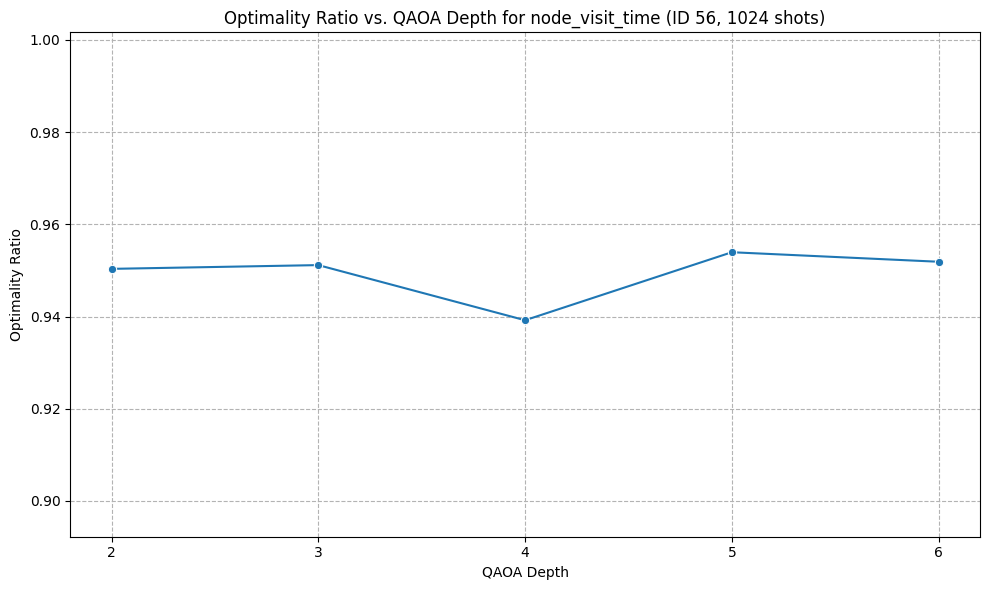

In [27]:
# --- Start of "Comparison of QAOA Depth" Analysis (Point 5 from PDF) ---

print("\n" + "="*80) # Separator for clarity
print("--- Comparison of QAOA Depth ---")
print("="*80 + "\n")

# Filter the data for the specific instance as per the analysis goal
# The user's print statement in the original code suggests the following filter:
# conf_qubit_alloc: 'node_visit_time', conf_target_id: 56, shots: 1024
depth_comparison_data = df_final[
    (df_final['conf_qubit_alloc'] == 'node_visit_time') &
    (df_final['conf_target_id'] == 56) &
    (df_final['shots'] == 1024)
].copy()

# Sort by QAOA depth for better visualization
depth_comparison_data = depth_comparison_data.sort_values(by='conf_qaoa_depth')

print(f"\n--- Optimality Ratio vs. QAOA Depth for 'node_visit_time' (conf_target_id=56, shots=1024) ---")
print(depth_comparison_data[['conf_qaoa_depth', 'shots', 'optimality_ratio', 'expected_cost', 'benchmark_min_cost_classical']])
print(f"\nNumber of data points for this comparison: {len(depth_comparison_data)}")

# Graph: Optimality Ratio vs. QAOA Depth
plt.figure(figsize=(10, 6))
sns.lineplot(x='conf_qaoa_depth', y='optimality_ratio', data=depth_comparison_data, marker='o', palette='plasma')

plt.title('Optimality Ratio vs. QAOA Depth for node_visit_time (ID 56, 1024 shots)')
plt.xlabel('QAOA Depth')
plt.ylabel('Optimality Ratio')
plt.xticks(depth_comparison_data['conf_qaoa_depth']) # Set specific x-ticks to depth values
plt.ylim(depth_comparison_data['optimality_ratio'].min() * 0.95, depth_comparison_data['optimality_ratio'].max() * 1.05) # Dynamic y-axis limits
plt.grid(True, which="both", ls="--", c='0.7') # Add a grid
plt.tight_layout()
plt.savefig('pic5.png')


--- Cost Distribution Analysis for Node Visit Time ---

--- Distribution of Normalized Cost for Node Visit Time ---
Normalized cost distribution plot saved as normalized_cost_distribution_node_visit_time_plot.png

--- Summary Statistics of Normalized Cost Distribution ---
                   count     mean       std  min  25%       50%      75%  max
conf_qubit_alloc                                                             
node_visit_time   1854.0  0.37109  0.411353  0.0  0.0  0.000002  0.53296  1.0


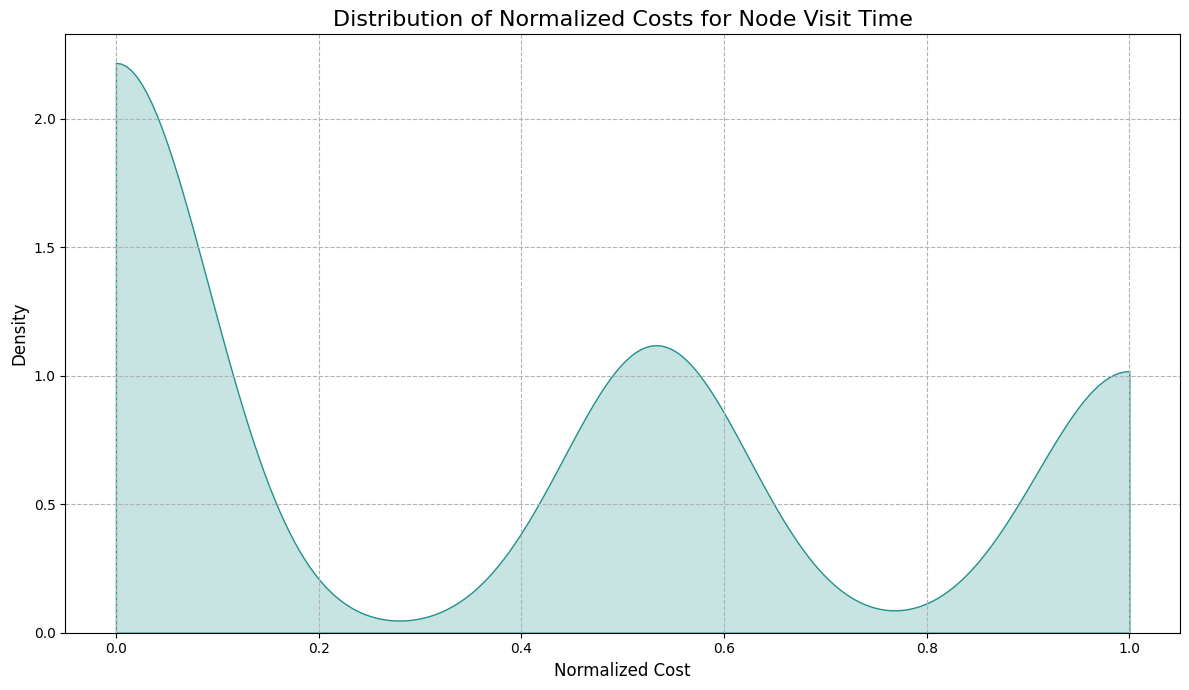

In [28]:
# --- Start of "Cost Distribution Analysis" (Point 6 from PDF) ---

print("\n" + "="*80)
print("--- Cost Distribution Analysis for Node Visit Time ---")
print("="*80 + "\n")

# Filter the data to include only 'node_visit_time'
df_filtered = df_quantum[df_quantum['conf_qubit_alloc'] == 'node_visit_time'].copy()

# Perform min-max normalization on the cost column
# Add a small epsilon to the denominator to prevent division by zero
epsilon = 1e-9
df_filtered['normalized_cost'] = (df_filtered['cost'] - df_filtered['benchmark_min_cost']) / (df_filtered['benchmark_max_cost'] - df_filtered['benchmark_min_cost'] + epsilon)

# Combine the data for a single plot, handling the count column.
# This creates a new DataFrame where each row is a single shot,
# allowing for correct distribution plotting.
cost_data_list = []
for index, row in df_filtered.iterrows():
    for _ in range(int(row['count'])):
        cost_data_list.append({
            'normalized_cost': row['normalized_cost'],
            'conf_qubit_alloc': row['conf_qubit_alloc']
        })

df_cost_distribution = pd.DataFrame(cost_data_list)

print("--- Distribution of Normalized Cost for Node Visit Time ---")

# Create a figure to hold the plots
plt.figure(figsize=(12, 7))

# Create a KDE plot (Kernel Density Estimate) to visualize the distribution
sns.kdeplot(data=df_cost_distribution, x='normalized_cost', hue='conf_qubit_alloc', fill=True, common_norm=False, palette='viridis', cut=0)

# Add titles and labels for clarity
plt.title('Distribution of Normalized Costs for Node Visit Time', fontsize=16)
plt.xlabel('Normalized Cost', fontsize=12)
plt.ylabel('Density', fontsize=12)

# Remove the legend since there is only one technique now
plt.legend([],[], frameon=False)

plt.grid(True, which="both", ls="--", c='0.7')
plt.tight_layout()

# Save the plot to a file
plt.savefig('normalized_cost_distribution_node_visit_time_plot.png')
print("Normalized cost distribution plot saved as normalized_cost_distribution_node_visit_time_plot.png")

# Additional summary statistics of the normalized cost distribution
cost_summary = df_cost_distribution.groupby('conf_qubit_alloc')['normalized_cost'].describe()

print("\n--- Summary Statistics of Normalized Cost Distribution ---")
print(cost_summary)


--- Optimality Ratio vs. Number of Nodes Table ---
   Nodes  avg_optimality_ratio
0      3              1.000000
1      4              0.934695
2      5              0.925009
3      6              0.778987

Number of data points for scaling analysis: 4
Optimality ratio vs. nodes plot saved as optimality_ratio_vs_nodes_plot.png


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3536\1350877814.py:53: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


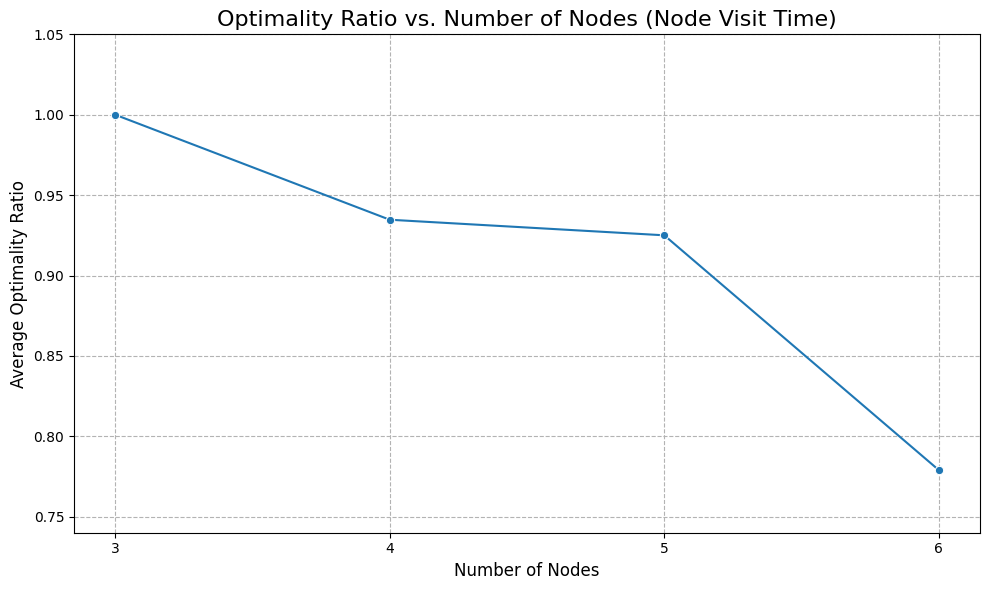

In [29]:
# Define the specific data points to filter
scaling_data_points = [
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 56, 'Nodes': 4},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 108, 'Nodes': 3},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 47, 'Nodes': 4},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_facility', 'conf_target_id': 5, 'Nodes': 6},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 103, 'Nodes': 4},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 63, 'Nodes': 5},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 78, 'Nodes': 3},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 21, 'Nodes': 3},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 90, 'Nodes': 4},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 14, 'Nodes': 4},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 79, 'Nodes': 5},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 45, 'Nodes': 5},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 81, 'Nodes': 6},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 80, 'Nodes': 6}
]

# Create a DataFrame from the specified data points to easily merge 'Nodes'
df_nodes_info = pd.DataFrame(scaling_data_points)

# Filter the df_final based on the specified 'conf_qubit_alloc' and 'conf_target_id'
df_scaling_analysis = df_final[
    (df_final['conf_qubit_alloc'] == 'node_visit_time') &
    (df_final['conf_target_id'].isin(df_nodes_info['conf_target_id']))
].copy()

# Merge the 'Nodes' information into the filtered DataFrame
df_scaling_analysis = pd.merge(
    df_scaling_analysis,
    df_nodes_info[['conf_target_id', 'Nodes']],
    on='conf_target_id',
    how='left'
)

# Remove rows with NaN in 'optimality_ratio' before grouping and averaging
df_scaling_analysis_no_nan = df_scaling_analysis.dropna(subset=['optimality_ratio'])

# Group by 'Nodes' and calculate the mean optimality ratio
df_scaling_analysis_grouped = df_scaling_analysis_no_nan.groupby('Nodes').agg(
    avg_optimality_ratio=('optimality_ratio', 'mean')
).reset_index()

# Sort by 'Nodes' for clear visualization
df_scaling_analysis_grouped = df_scaling_analysis_grouped.sort_values(by='Nodes')

print("\n--- Optimality Ratio vs. Number of Nodes Table ---")
print(df_scaling_analysis_grouped[['Nodes', 'avg_optimality_ratio']])
print(f"\nNumber of data points for scaling analysis: {len(df_scaling_analysis_grouped)}")

# Graph: Optimality Ratio vs. Number of Nodes
plt.figure(figsize=(10, 6))
sns.lineplot(
    x='Nodes',
    y='avg_optimality_ratio',
    data=df_scaling_analysis_grouped,
    marker='o',
    palette='viridis'
)

plt.title('Optimality Ratio vs. Number of Nodes (Node Visit Time)', fontsize=16)
plt.xlabel('Number of Nodes', fontsize=12)
plt.ylabel('Average Optimality Ratio', fontsize=12)
plt.xticks(df_scaling_analysis_grouped['Nodes']) # Set specific x-ticks to node values
plt.ylim(df_scaling_analysis_grouped['avg_optimality_ratio'].min() * 0.95, df_scaling_analysis_grouped['avg_optimality_ratio'].max() * 1.05)
plt.grid(True, which="both", ls="--", c='0.7')
plt.tight_layout()

# Save the plot to a file
plt.savefig('optimality_ratio_vs_nodes_plot.png')
print("Optimality ratio vs. nodes plot saved as optimality_ratio_vs_nodes_plot.png")


--- Optimality Ratio vs. Number of Nodes Table ---
   Nodes  avg_optimality_ratio
0      3              1.000000
1      4              0.981643

Number of data points for scaling analysis: 2
Optimality ratio vs. nodes plot saved as optimality_ratio_vs_nodes_plot.png


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3536\1520198382.py:53: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


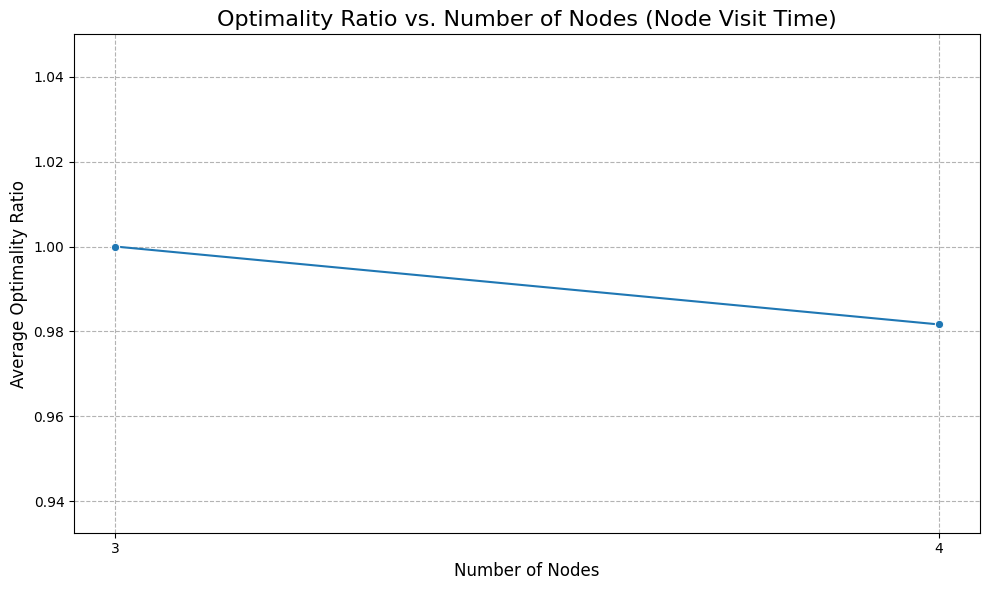

In [30]:
# Define the specific data points to filter
scaling_data_points = [
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 56, 'Nodes': 4},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 108, 'Nodes': 3},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 47, 'Nodes': 4},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_facility', 'conf_target_id': 5, 'Nodes': 6},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 103, 'Nodes': 4},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 63, 'Nodes': 5},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 78, 'Nodes': 3},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 21, 'Nodes': 3},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 90, 'Nodes': 4},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 14, 'Nodes': 4},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 79, 'Nodes': 5},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 45, 'Nodes': 5},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 81, 'Nodes': 6},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 80, 'Nodes': 6}
]

# Create a DataFrame from the specified data points to easily merge 'Nodes'
df_nodes_info = pd.DataFrame(scaling_data_points)

# Filter the df_final based on the specified 'conf_qubit_alloc' and 'conf_target_id'
df_scaling_analysis = df_final[
    (df_final['conf_qubit_alloc'] == 'naive_adjacency') &
    (df_final['conf_target_id'].isin(df_nodes_info['conf_target_id']))
].copy()

# Merge the 'Nodes' information into the filtered DataFrame
df_scaling_analysis = pd.merge(
    df_scaling_analysis,
    df_nodes_info[['conf_target_id', 'Nodes']],
    on='conf_target_id',
    how='left'
)

# Remove rows with NaN in 'optimality_ratio' before grouping and averaging
df_scaling_analysis_no_nan = df_scaling_analysis.dropna(subset=['optimality_ratio'])

# Group by 'Nodes' and calculate the mean optimality ratio
df_scaling_analysis_grouped = df_scaling_analysis_no_nan.groupby('Nodes').agg(
    avg_optimality_ratio=('optimality_ratio', 'mean')
).reset_index()

# Sort by 'Nodes' for clear visualization
df_scaling_analysis_grouped = df_scaling_analysis_grouped.sort_values(by='Nodes')

print("\n--- Optimality Ratio vs. Number of Nodes Table ---")
print(df_scaling_analysis_grouped[['Nodes', 'avg_optimality_ratio']])
print(f"\nNumber of data points for scaling analysis: {len(df_scaling_analysis_grouped)}")

# Graph: Optimality Ratio vs. Number of Nodes
plt.figure(figsize=(10, 6))
sns.lineplot(
    x='Nodes',
    y='avg_optimality_ratio',
    data=df_scaling_analysis_grouped,
    marker='o',
    palette='viridis'
)

plt.title('Optimality Ratio vs. Number of Nodes (Node Visit Time)', fontsize=16)
plt.xlabel('Number of Nodes', fontsize=12)
plt.ylabel('Average Optimality Ratio', fontsize=12)
plt.xticks(df_scaling_analysis_grouped['Nodes']) # Set specific x-ticks to node values
plt.ylim(df_scaling_analysis_grouped['avg_optimality_ratio'].min() * 0.95, df_scaling_analysis_grouped['avg_optimality_ratio'].max() * 1.05)
plt.grid(True, which="both", ls="--", c='0.7')
plt.tight_layout()

# Save the plot to a file
plt.savefig('optimality_ratio_vs_nodes_plot.png')
print("Optimality ratio vs. nodes plot saved as optimality_ratio_vs_nodes_plot.png")


--- Combined Optimality Ratio vs. Number of Nodes Table ---
  conf_qubit_alloc  Nodes  avg_optimality_ratio
0  node_visit_time      3              1.000000
1  node_visit_time      4              0.934695
2  node_visit_time      5              0.925009
3  node_visit_time      6              0.778987
0  naive_adjacency      3              1.000000
1  naive_adjacency      4              0.981643


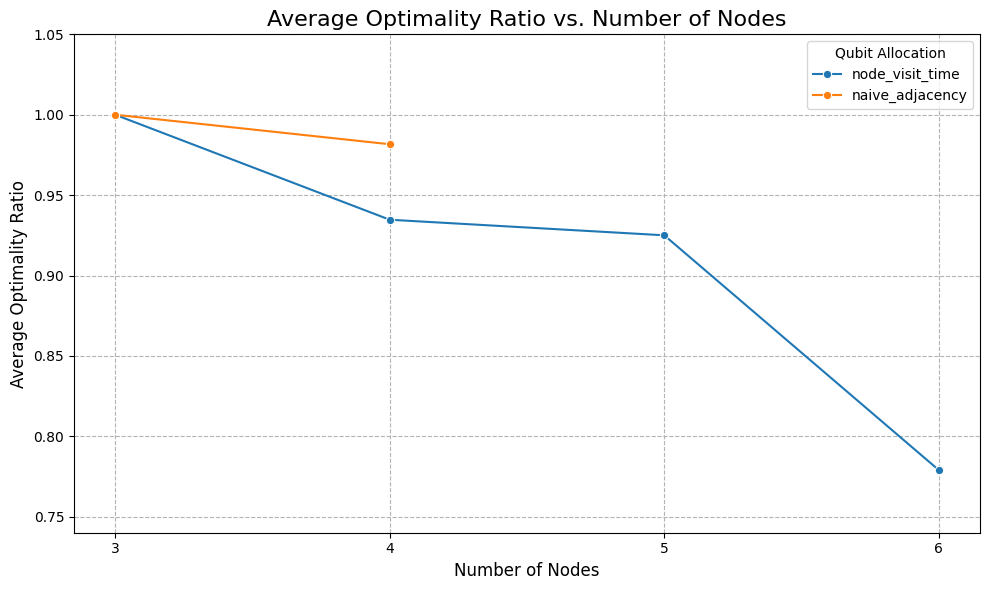

In [32]:
# Define the specific data points to filter
scaling_data_points = [
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 56, 'Nodes': 4},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 108, 'Nodes': 3},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 47, 'Nodes': 4},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_facility', 'conf_target_id': 5, 'Nodes': 6},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 103, 'Nodes': 4},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 63, 'Nodes': 5},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 78, 'Nodes': 3},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 21, 'Nodes': 3},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 90, 'Nodes': 4},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 14, 'Nodes': 4},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 79, 'Nodes': 5},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 45, 'Nodes': 5},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 81, 'Nodes': 6},
    {'conf_qubit_alloc': 'node_visit_time', 'conf_cluster_type': 'waste_collection_area', 'conf_target_id': 80, 'Nodes': 6}
]

# Create a DataFrame from the specified data points to easily merge 'Nodes'
df_nodes_info = pd.DataFrame(scaling_data_points)

# --- Analysis for 'node_visit_time' ---
df_scaling_analysis_nvt = df_final[
    (df_final['conf_qubit_alloc'] == 'node_visit_time') &
    (df_final['conf_target_id'].isin(df_nodes_info['conf_target_id']))
].copy()

df_scaling_analysis_nvt = pd.merge(
    df_scaling_analysis_nvt,
    df_nodes_info[['conf_target_id', 'Nodes']],
    on='conf_target_id',
    how='left'
)

df_scaling_analysis_nvt = df_scaling_analysis_nvt.dropna(subset=['optimality_ratio'])
df_scaling_analysis_nvt_grouped = df_scaling_analysis_nvt.groupby('Nodes').agg(
    avg_optimality_ratio=('optimality_ratio', 'mean')
).reset_index()
df_scaling_analysis_nvt_grouped['conf_qubit_alloc'] = 'node_visit_time'

# --- Analysis for 'naive_adjacency' ---
# Reuse the same df_nodes_info for merging
df_scaling_analysis_na = df_final[
    (df_final['conf_qubit_alloc'] == 'naive_adjacency') &
    (df_final['conf_target_id'].isin(df_nodes_info['conf_target_id']))
].copy()

df_scaling_analysis_na = pd.merge(
    df_scaling_analysis_na,
    df_nodes_info[['conf_target_id', 'Nodes']],
    on='conf_target_id',
    how='left'
)

df_scaling_analysis_na = df_scaling_analysis_na.dropna(subset=['optimality_ratio'])
df_scaling_analysis_na_grouped = df_scaling_analysis_na.groupby('Nodes').agg(
    avg_optimality_ratio=('optimality_ratio', 'mean')
).reset_index()
df_scaling_analysis_na_grouped['conf_qubit_alloc'] = 'naive_adjacency'

# Combine the two dataframes for plotting
df_combined = pd.concat([df_scaling_analysis_nvt_grouped, df_scaling_analysis_na_grouped])

print("\n--- Combined Optimality Ratio vs. Number of Nodes Table ---")
print(df_combined[['conf_qubit_alloc', 'Nodes', 'avg_optimality_ratio']])

# Graph: Optimality Ratio vs. Number of Nodes for both methods
plt.figure(figsize=(10, 6))
sns.lineplot(
    x='Nodes',
    y='avg_optimality_ratio',
    hue='conf_qubit_alloc',
    data=df_combined,
    marker='o'
)

plt.title('Average Optimality Ratio vs. Number of Nodes', fontsize=16)
plt.xlabel('Number of Nodes', fontsize=12)
plt.ylabel('Average Optimality Ratio', fontsize=12)
plt.xticks(sorted(df_combined['Nodes'].unique())) # Set specific x-ticks to node values
plt.ylim(df_combined['avg_optimality_ratio'].min() * 0.95, df_combined['avg_optimality_ratio'].max() * 1.05)
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend(title='Qubit Allocation')
plt.tight_layout()

# Show the plot
plt.savefig('picpic.png')